# Business Performance & Profitability Analysis for an E-Commerce Retailer

Prepared By: Shruti Patidar

Tools: Python, Pandas, Plotly, Jupyter Notebook

# Business Problem<b>

An e-commerce retailer wants to improve profitability and identify growth opportunities by analyzing sales transactions across products, customer segments, and regions.<br>

The business needs to understand:<br>

• Which products generate the most revenue and profit<br>
• Which products are causing losses<br>
• Which customer segments are most valuable<br>
• How sales and profit change over time<br>
• What actions can be taken to improve overall business performance

# Executive Summary
This analysis was conducted on 9,994 e-commerce transactions to identify key revenue drivers, profitability trends, customer value, and business improvement opportunities.

Key Findings:

• November generated the highest sales revenue, while December delivered the highest profit.

• Technology was the strongest-performing category, generating the highest revenue and profit margin (15.61%).

• Furniture generated significant sales but achieved the lowest profit margin (3.88%), indicating profitability challenges.

• Discounts above 30% consistently resulted in negative average profits, reducing overall business profitability.

• The West region generated the highest sales, profit, and profit margin.

• Texas was the largest loss-making state, primarily due to poor performance in Office Supplies and Furniture.

• Binders were the biggest contributor to losses in Texas, accounting for more than $14K in negative profit.

• Consumer customers generated the highest revenue and profit, while Home Office customers showed the strongest profit efficiency.

The findings highlight opportunities to improve profitability through pricing optimization, discount management, product portfolio improvements, and targeted customer retention strategies.

# Project Overview

This project analyzes 9,994 retail transactions from an e-commerce business to identify revenue drivers, profitability trends, customer behavior, and geographic performance.

The objective is to transform raw transaction data into actionable business insights that support pricing decisions, inventory planning, customer retention, and profitability optimization.

# Tools Used

- Python
- Pandas
- Plotly
- Jupyter Notebook
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Business Analysis
- Data Visualization

# Dataset Information

Dataset: Sample Superstore Dataset

Total Records: 9,994

Description:

The dataset contains transaction-level sales data from an e-commerce retailer. It includes customer information, order details, product information, sales performance, discounts, and profitability metrics used to evaluate business performance and identify growth opportunities.

Columns Included:

- Row ID
- Order ID
- Order Date
- Ship Date
- Ship Mode
- Customer ID
- Customer Name
- Segment
- Country
- City
- State
- Postal Code
- Region
- Product ID
- Category
- Sub-Category
- Product Name
- Sales
- Quantity
- Discount
- Profit

# Project Workflow

1. Business Understanding

2. Data Collection and Loading

3. Data Cleaning and Preparation

4. Feature Engineering

5. Sales Analysis

6. Profitability Analysis

7. Customer Segment Analysis

8. Discount Impact Analysis

9. Regional and State Analysis

10. Root Cause Analysis

11. Business Recommendations

12. Business Impact Assessment

# Business Objective

The primary objective of this project is to identify key revenue drivers, profitability trends, customer value, and geographic performance patterns within the business.

The analysis aims to:

• Identify high-performing products and categories.

• Detect loss-making products and regions.

• Evaluate the impact of discounts on profitability.

• Understand customer segment performance.

• Support data-driven business decisions through actionable recommendations.

In [1]:
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.colors as colors
pio.templates.default = "plotly_white"

In [2]:
data = pd.read_csv('Sample - Superstore.csv', encoding = 'latin-1')

In [3]:
data.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [4]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

# Data Cleaning and Preparation

To ensure accurate analysis, the following data preparation steps were performed:

• Examined dataset structure, data types, and summary statistics.

• Verified data completeness and consistency.

• Converted Order Date and Ship Date columns into datetime format.

• Created new time-based features including:
  - Month Number
  - Order Month
  - Order Year
  - Order Day of Week

These transformations enabled trend analysis, seasonal pattern identification, and time-based business insights.

# Converting Date Columns

In [6]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

# Feature Engineering

To support business analysis and trend identification, additional time-based features were created from the Order Date field.

Features Created:

• Month Number – for chronological month sorting.

• Order Month – for monthly sales and profit analysis.

• Order Year – for year-level trend analysis.

• Order Day of Week – for future weekday performance analysis.

These engineered features enabled time-series analysis and improved business insight generation.

In [8]:
data['Month Number'] = data['Order Date'].dt.month
data['Order Month'] = data['Order Date'].dt.month_name().str[:3]
data['Order Year'] = data['Order Date'].dt.year
data['Order Day of Week'] = data['Order Date'].dt.dayofweek

# Business Analysis

After preparing the dataset, a series of analyses were conducted to evaluate sales performance, profitability, customer behavior, discount effectiveness, and geographic trends.

The objective of this analysis is to identify business opportunities, uncover profitability risks, and generate actionable recommendations that support data-driven decision-making.

## Which months generate the highest revenue and what seasonal patterns can help improve sales planning?

In [9]:
sales_by_month = data.groupby(['Month Number','Order Month'])['Sales'].sum().reset_index()
sales_by_month

,Month Number,Order Month,Sales
0,1,Jan,94924.8356
1,2,Feb,59751.2514
2,3,Mar,205005.4888
3,4,Apr,137762.1286
4,5,May,155028.8117
5,6,Jun,152718.6793
6,7,Jul,147238.0970
7,8,Aug,159044.0630
8,9,Sep,307649.9457
9,10,Oct,200322.9847


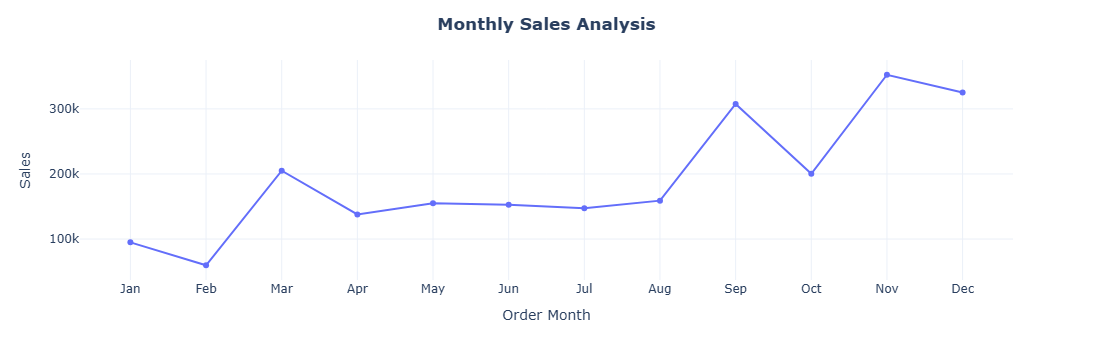

In [10]:
fig = px.line(
              sales_by_month,
              x = 'Order Month',
              y = 'Sales',
              markers = True
)
fig.update_layout(
    title = {
        'text' : '<b>Monthly Sales Analysis</b>',
        'x' : 0.5,
        'xanchor'  : 'center'
    },
    template = 'plotly_white'
)
fig.show()

## Insight:

Sales demonstrate a strong seasonal pattern, with revenue increasing significantly during Q4 and peaking in November.

This trend suggests that customer demand rises sharply during the holiday season, making Q4 the most critical period for revenue generation.

The business should prioritize inventory planning, marketing campaigns, and promotional activities during this period to maximize sales opportunities and avoid stock shortages.

## Business Value:

Understanding seasonal demand patterns enables better inventory management, workforce planning, and marketing budget allocation, helping the business maximize revenue during peak periods.

## Which product categories contribute the most revenue and should receive greater business focus?

In [11]:
sales_by_category = data.groupby('Category')['Sales'].sum().reset_index()
sales_by_category

,Category,Sales
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


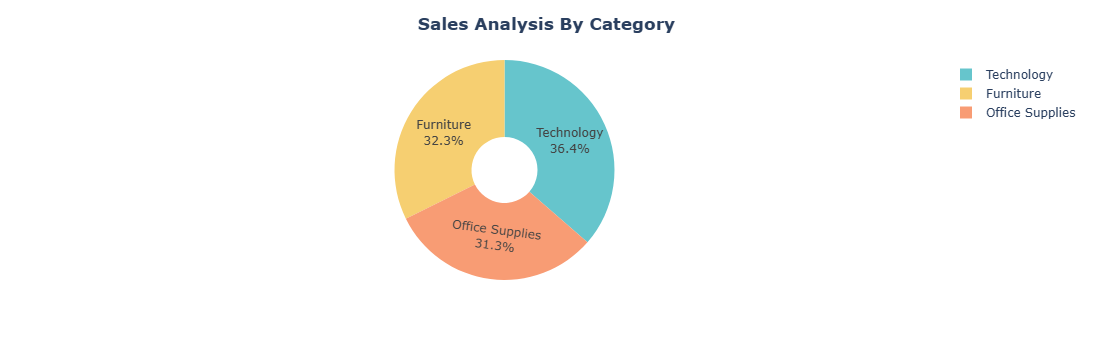

In [12]:
fig = px.pie(
              sales_by_category,
              names = 'Category',
              values = 'Sales',
              hole = 0.3,
              color_discrete_sequence = px.colors.qualitative.Pastel
)
fig.update_traces(
    textposition = 'inside',
    textinfo = 'percent+label'
)
fig.update_layout(
    title = {
        'text' : '<b>Sales Analysis By Category</b>',
        'x' : 0.5,
        'xanchor'  : 'center'
    }
)
fig.show()

## Insight:

Technology generated the highest sales revenue ($836K), making it the largest contributor to overall business revenue.

Furniture and Office Supplies also contributed significantly, generating over $700K each in sales, indicating that revenue is distributed across multiple product categories rather than relying on a single category.

## Business Value:

Understanding category-level revenue helps the business identify key revenue drivers, optimize inventory allocation, and prioritize marketing efforts toward high-performing product categories.

## Recommendation:

• Continue investing in Technology products due to their strong revenue contribution.

• Maintain a balanced product portfolio across all categories to reduce dependency on a single revenue source.

• Further analyze category profitability to ensure high sales are translating into business profit.

## Which product sub-categories are the primary revenue drivers and which require performance improvement?

In [13]:
sales_by_subcategory = data.groupby('Sub-Category')['Sales'].sum().reset_index()
sales_by_subcategory

,Sub-Category,Sales
0,Accessories,167380.3180
1,Appliances,107532.1610
2,Art,27118.7920
3,Binders,203412.7330
4,Bookcases,114879.9963
5,Chairs,328449.1030
6,Copiers,149528.0300
7,Envelopes,16476.4020
8,Fasteners,3024.2800
9,Furnishings,91705.1640


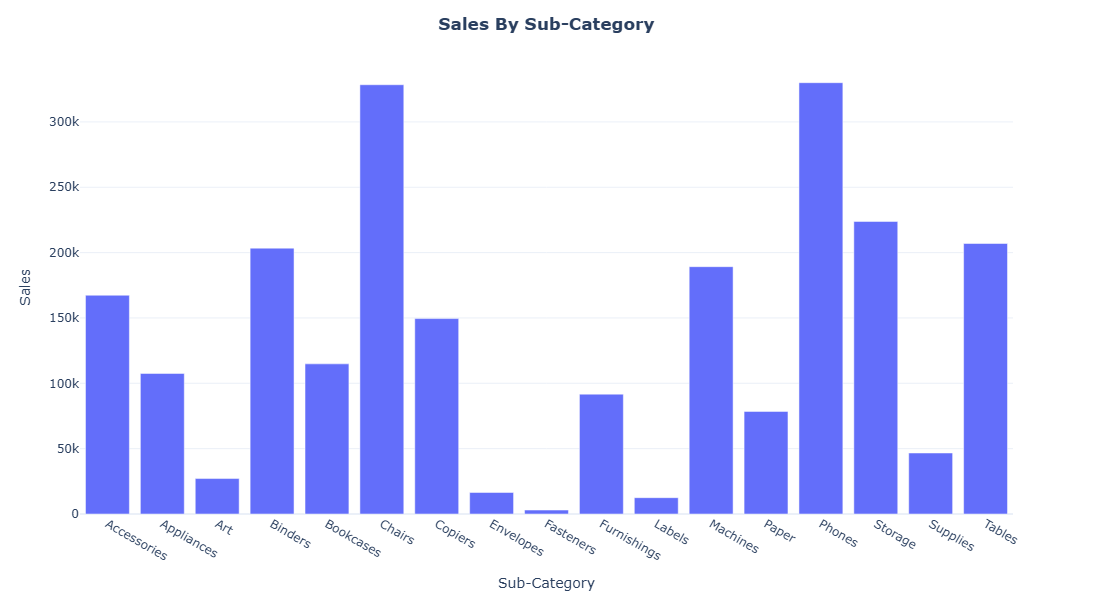

In [14]:
fig = px.bar(
              sales_by_subcategory,
              x = 'Sub-Category',
              y = 'Sales'
)
fig.update_layout(
    title = {
        'text' : '<b>Sales By Sub-Category</b>',
        'x' : 0.5,
        'xanchor'  : 'center'
    },
    template = 'plotly_white',
    height = 600
)
fig.show()

## Insight:

Phones and Chairs emerged as the highest revenue-generating sub-categories, each contributing more than $325K in sales.

Storage, Tables, and Binders also generated substantial revenue, making them important contributors to overall business performance.

Revenue is concentrated among a small group of sub-categories, indicating that business growth is heavily influenced by the performance of these product lines.

## Business Value:

Sub-category analysis provides a more detailed understanding of product performance and helps identify specific product groups that drive business growth. This information supports inventory planning, demand forecasting, and promotional decision-making.

## Recommendation:

• Prioritize inventory availability for high-demand sub-categories such as Phones and Chairs.

• Monitor the performance of key revenue-driving sub-categories to ensure consistent sales growth.

• Conduct profitability analysis on high-revenue sub-categories to verify that revenue is translating into profit.

## Which months generate the highest profit and how does profitability change throughout the year?

In [15]:
profit_by_month = data.groupby(['Month Number','Order Month'])['Profit'].sum().reset_index()
profit_by_month

,Month Number,Order Month,Profit
0,1,Jan,9134.4461
1,2,Feb,10294.6107
2,3,Mar,28594.6872
3,4,Apr,11587.4363
4,5,May,22411.3078
5,6,Jun,21285.7954
6,7,Jul,13832.6648
7,8,Aug,21776.9384
8,9,Sep,36857.4753
9,10,Oct,31784.0413


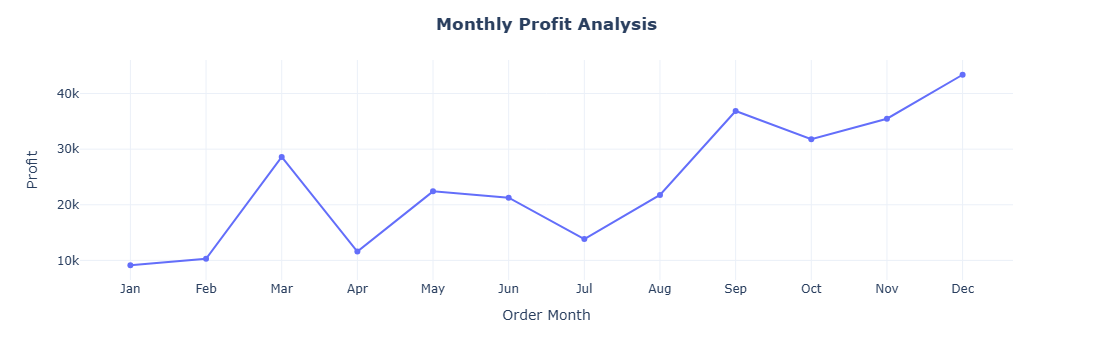

In [16]:
fig = px.line(
              profit_by_month,
              x = 'Order Month',
              y = 'Profit',
              markers = True
)
fig.update_layout(
    title = {
        'text' : '<b>Monthly Profit Analysis</b>',
        'x' : 0.5,
        'xanchor'  : 'center'
    },
    template = 'plotly_white'
)
fig.show()

## Insight:

Profitability increased significantly during the second half of the year, with December generating the highest profit ($43.4K).

The final quarter (October–December) consistently delivered strong profits, indicating that seasonal demand not only increases sales but also contributes positively to overall profitability.

This suggests that year-end business activity is a major driver of financial performance.

## Business Value:

Profit trend analysis helps the business identify periods of high profitability and supports strategic planning for inventory management, workforce allocation, and marketing investments during peak seasons.

## Recommendation:

• Increase inventory and operational readiness during Q4 to capitalize on peak profitability.

• Allocate additional marketing budget during high-profit periods to maximize returns.

• Investigate factors contributing to strong Q4 performance and replicate successful strategies throughout the year.

## Which product categories generate the greatest profit and which contribute less to overall business profitability?

In [17]:
profit_by_category = data.groupby('Category')['Profit'].sum().reset_index()
profit_by_category

,Category,Profit
0,Furniture,18451.2728
1,Office Supplies,122490.8008
2,Technology,145454.9481


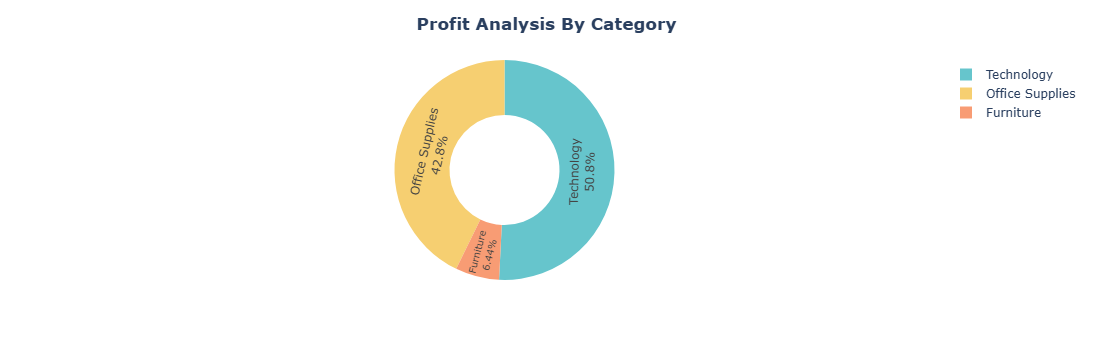

In [18]:
fig = px.pie(
              profit_by_category,
              names = 'Category',
              values = 'Profit',
              hole = 0.5,
              color_discrete_sequence = px.colors.qualitative.Pastel
)
fig.update_traces(
    textposition = 'inside',
    textinfo = 'percent+label'
)
fig.update_layout(
    title = {
        'text' : '<b>Profit Analysis By Category</b>',
        'x' : 0.5,
        'xanchor'  : 'center'
    }
)
fig.show()

## # Insight

Technology generated the highest profit ($145K), making it the most profitable category for the business.

Office Supplies also contributed significantly, generating over $122K in profit.

Although Furniture generated substantial sales revenue, it produced only $18K in profit, indicating weaker profitability compared to the other categories.

## Business Value

Profit analysis helps identify which product categories contribute most to the company's financial performance. Understanding category profitability enables better resource allocation and supports strategic investment decisions.

## Recommendation

• Increase focus on Technology products due to their strong profit contribution.

• Continue expanding profitable Office Supplies product lines.

• Investigate the low profitability of Furniture products to identify pricing, discounting, or cost-related issues.

## Which sub-categories generate profits and which are responsible for business losses?

In [19]:
profit_by_subcategory = data.groupby('Sub-Category')['Profit'].sum().reset_index()
profit_by_subcategory

,Sub-Category,Profit
0,Accessories,41936.6357
1,Appliances,18138.0054
2,Art,6527.7870
3,Binders,30221.7633
4,Bookcases,-3472.5560
5,Chairs,26590.1663
6,Copiers,55617.8249
7,Envelopes,6964.1767
8,Fasteners,949.5182
9,Furnishings,13059.1436


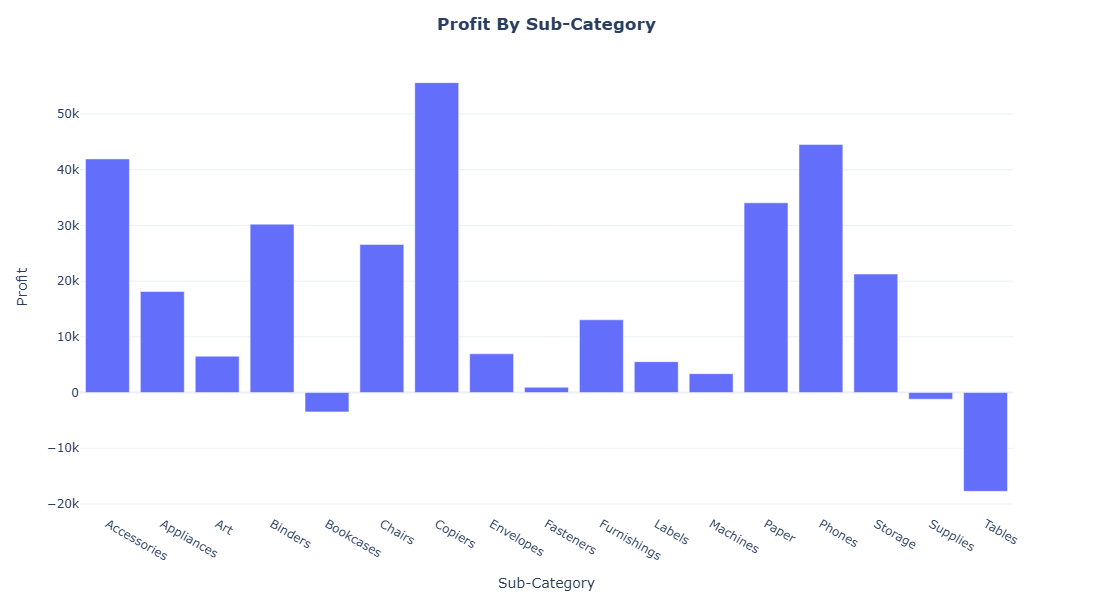

In [20]:
fig = px.bar(
              profit_by_subcategory,
              x = 'Sub-Category',
              y = 'Profit'
)
fig.update_layout(
    title = {
        'text' : '<b>Profit By Sub-Category</b>',
        'x' : 0.5,
        'xanchor'  : 'center'
    },
    template = 'plotly_white',
    height = 600
)
fig.show()

## Insight

Copiers generated the highest profit ($55.6K), followed by Phones ($44.5K), Accessories ($41.9K), and Paper ($34.1K), making them the strongest profit contributors.

However, Tables (-$17.7K), Bookcases (-$3.5K), and Supplies (-$1.2K) generated losses despite producing sales revenue.

This indicates that some products contribute to revenue growth while reducing overall profitability.

## Business Value

Sub-category profitability analysis helps identify specific product groups that create value and those that negatively impact financial performance. This enables more targeted business decisions than category-level analysis alone.

## Recommendation

• Increase focus on high-profit sub-categories such as Copiers, Phones, Accessories, and Paper.

• Review pricing, discounting, and cost structures for Tables, Bookcases, and Supplies.

• Monitor loss-making sub-categories regularly to prevent further margin erosion.

## Which customer segments create the most value for the business in terms of revenue and profit?

In [21]:
sales_profit_by_segment = data.groupby('Segment').agg({'Sales':'sum', 'Profit':'sum'}).reset_index()
sales_profit_by_segment

,Segment,Sales,Profit
0,Consumer,1.161401e+06,134119.2092
1,Corporate,7.061464e+05,91979.1340
2,Home Office,4.296531e+05,60298.6785


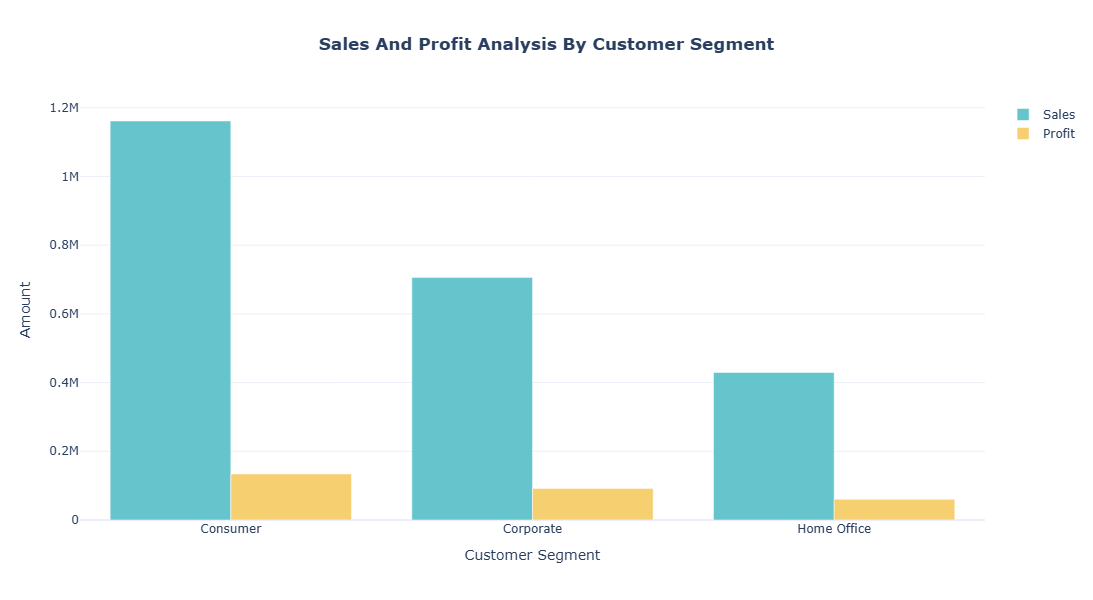

In [22]:
color_palette = colors.qualitative.Pastel

fig = go.Figure()
fig.add_trace (go.Bar(x = sales_profit_by_segment['Segment'],
                     y = sales_profit_by_segment['Sales'],
              name = 'Sales',
              marker_color = color_palette[0]))

fig.add_trace (go.Bar(x = sales_profit_by_segment['Segment'],
                     y = sales_profit_by_segment['Profit'],
              name = 'Profit',
              marker_color = color_palette[1]))
fig.update_layout(
    title = {
        'text' : '<b>Sales And Profit Analysis By Customer Segment</b>',
        'x' : 0.5,
        'xanchor'  : 'center'
    },
    xaxis_title = 'Customer Segment',
    yaxis_title = 'Amount',
    template = 'plotly_white',
    height = 600
)
fig.show()

## Insight

The Consumer segment generated the highest sales (1.16M) and profit (134K), making it the most valuable customer group for the business.

The Corporate segment contributed significantly to both revenue and profit, while the Home Office segment generated the lowest overall sales and profit.

The business currently relies heavily on Consumer customers for revenue generation and profitability.

## Business Value

Customer segment analysis helps identify the most valuable customer groups and supports customer retention, marketing, and acquisition strategies. Understanding segment performance enables the business to allocate resources more effectively.

## Recommendation

• Prioritize retention initiatives for Consumer customers to protect a major source of revenue and profit.

• Develop targeted marketing campaigns for Corporate customers to increase revenue contribution.

• Explore opportunities to grow the Home Office segment through specialized offers and promotions.

## Which customer segment converts sales into profit most efficiently?

In [23]:
sales_profit_by_segment = data.groupby('Segment').agg({'Sales':'sum', 'Profit':'sum'}).reset_index()
sales_profit_by_segment['sales_profit_ratio'] = sales_profit_by_segment['Sales']/sales_profit_by_segment['Profit']
print(sales_profit_by_segment[['Segment','sales_profit_ratio']])

       Segment  sales_profit_ratio
0     Consumer            8.659471
1    Corporate            7.677245
2  Home Office            7.125416


## Insight

The Home Office segment achieved the lowest sales-to-profit ratio (7.13), making it the most efficient segment at converting revenue into profit.

Corporate customers followed with a ratio of 7.68, while the Consumer segment recorded the highest ratio of 8.66.

Although Consumer customers generate the highest revenue and profit, Home Office customers generate more profit relative to their sales volume.

## Business Value

Sales-to-profit ratio analysis helps evaluate customer segment efficiency rather than focusing only on revenue. This enables the business to identify customer groups that generate higher profitability and support more sustainable growth.

## Recommendation

• Analyze purchasing behavior within the Home Office segment to identify factors driving higher profitability.

• Apply successful strategies from the Home Office segment to other customer groups where possible.

• Continue growing the Consumer segment while monitoring profitability efficiency alongside revenue growth.

## Which product categories generate the highest profit margin and deliver the greatest profitability relative to sales?

In [24]:
data['Profit Margin %'] = (data['Profit'] / data['Sales']) * 100

In [25]:
profit_margin_category = data.groupby('Category')['Profit Margin %'].mean().reset_index()
profit_margin_category

,Category,Profit Margin %
0,Furniture,3.878353
1,Office Supplies,13.803029
2,Technology,15.613805


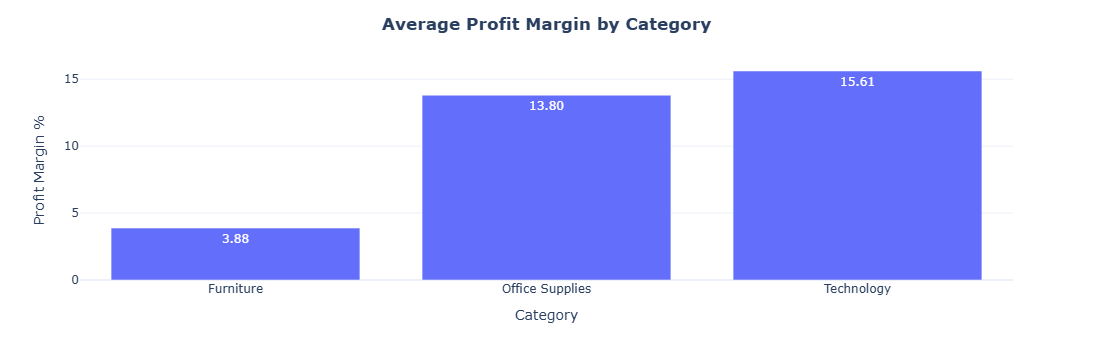

In [26]:
fig = px.bar(
    profit_margin_category,
    x='Category',
    y='Profit Margin %',
    text_auto='.2f'
)

fig.update_layout(
    title={
        'text':'<b>Average Profit Margin by Category</b>',
        'x':0.5,
        'xanchor':'center'
    },
    template='plotly_white'
)

fig.show()

## Insight

Technology achieved the highest profit margin (15.61%), making it the most profitable category relative to revenue.

Office Supplies also demonstrated strong profitability with a profit margin of 13.80%.

In contrast, Furniture generated a profit margin of only 3.88%, indicating that a large portion of its revenue is being consumed by costs, discounting, or low-margin products.

## Business Value

Profit margin analysis provides a more accurate measure of business performance than sales alone. It helps identify which categories generate the highest return on revenue and supports strategic decisions related to pricing, inventory, and product investment.

## Recommendation

• Increase investment in Technology products due to their strong revenue generation and highest profit margin.

• Expand profitable Office Supplies product lines where feasible.

• Review pricing, discounting, and product mix strategies within Furniture to improve profitability.

• Investigate loss-making Furniture sub-categories such as Tables and Bookcases to identify margin improvement opportunities.

## Are discounts helping increase sales profitably, or are they negatively impacting business margins?

In [27]:
discount_analysis = (data.groupby('Discount').agg({'Sales':'mean','Profit':'mean'}).reset_index())
discount_analysis

,Discount,Sales,Profit
0,0.00,226.742074,66.900292
1,0.10,578.397351,96.055074
2,0.15,529.971567,27.288298
3,0.20,209.076940,24.702572
4,0.30,454.742974,-45.679636
5,0.32,536.794770,-88.560656
6,0.40,565.134874,-111.927429
7,0.45,498.634000,-226.646464
8,0.50,892.705152,-310.703456
9,0.60,48.150000,-43.077212


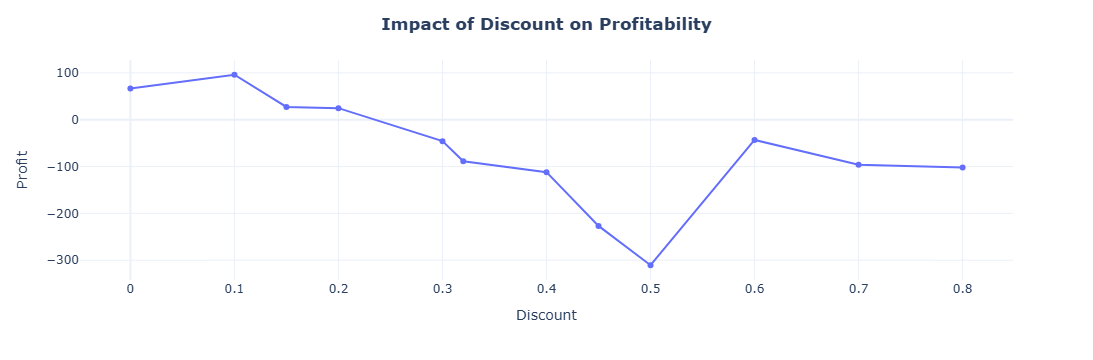

In [28]:
discount_profit = (
    data.groupby('Discount')['Profit']
    .mean()
    .reset_index()
)

fig = px.line(
    discount_profit,
    x='Discount',
    y='Profit',
    markers=True
)

fig.update_layout(
    title={
        'text':'<b>Impact of Discount on Profitability</b>',
        'x':0.5,
        'xanchor':'center'
    },
    template='plotly_white'
)

fig.show()

## Insight

Discounts up to 20% generally maintain positive profitability while supporting sales performance.

However, once discounts exceed 30%, average profit becomes negative despite continued sales activity.

The 50% discount level generated the highest average sales value ($892.71) but also resulted in the largest average loss (-310.70), indicating that revenue growth is being achieved at the expense of profitability.

## Business Value

Discount analysis helps the business understand the relationship between promotional strategies and profitability. Identifying discount levels that negatively impact margins enables more effective pricing decisions and protects long-term financial performance.

## Recommendation

• Limit discount levels above 30% unless supported by specific strategic objectives.

• Review products frequently sold with discounts of 40%–50% to identify profitability risks.

• Focus promotional strategies within the 0%–20% discount range where sales and profitability remain positive.

• Implement profitability monitoring for promotional campaigns to ensure revenue growth does not come at the expense of margins.

## Which regions contribute the most revenue and profit, and where should the business focus future growth investments?

In [29]:
region_analysis = (
    data.groupby('Region')
    .agg({
        'Sales':'sum',
        'Profit':'sum'
    })
    .reset_index()
)

region_analysis

,Region,Sales,Profit
0,Central,501239.8908,39706.3625
1,East,678781.2400,91522.7800
2,South,391721.9050,46749.4303
3,West,725457.8245,108418.4489


## Insight

The West region generated the highest sales ($725K) and profit ($108K), making it the strongest-performing market for the business.

The East region also delivered strong performance, contributing $679K in sales and $92K in profit.

Although the Central region generated over $500K in sales, its profitability remained significantly lower than both the West and East regions.

## Business Value

Regional performance analysis helps identify geographic markets that drive business growth and profitability. Understanding regional differences supports market expansion, resource allocation, and investment decisions.

## Recommendation

• Continue investing in West and East regions through marketing, inventory expansion, and customer acquisition initiatives.

• Investigate factors limiting profitability in the Central region.

• Explore growth opportunities in the South region to increase revenue contribution and market share.

• Use successful sales strategies from high-performing regions as benchmarks for other markets.

## Which region generates the highest profitability relative to revenue?

In [30]:
region_analysis['Profit Margin %'] = (
    region_analysis['Profit'] /
    region_analysis['Sales']
) * 100

region_analysis

,Region,Sales,Profit,Profit Margin %
0,Central,501239.8908,39706.3625,7.921629
1,East,678781.2400,91522.7800,13.483399
2,South,391721.9050,46749.4303,11.934342
3,West,725457.8245,108418.4489,14.944831


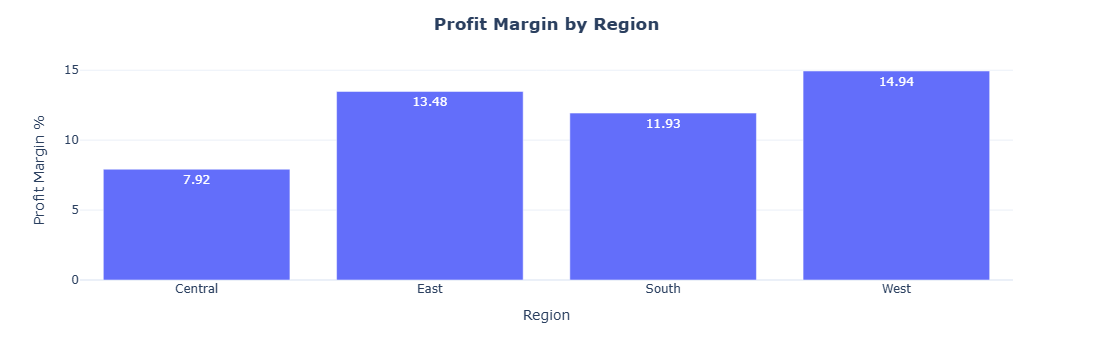

In [31]:
fig = px.bar(
    region_analysis,
    x='Region',
    y='Profit Margin %',
    text_auto='.2f'
)

fig.update_layout(
    title={
        'text':'<b>Profit Margin by Region</b>',
        'x':0.5,
        'xanchor':'center'
    },
    template='plotly_white'
)

fig.show()

## Insight

The West region achieved the highest profit margin (14.94%), making it the most efficient and profitable market for the business.

The East region also demonstrated strong profitability with a profit margin of 13.48%.

In contrast, the Central region generated a profit margin of only 7.92%, indicating that a significant portion of its revenue is not translating into profit.

## Business Value

Profit margin analysis provides a deeper understanding of regional performance by evaluating profitability efficiency rather than revenue alone. This helps identify markets that generate sustainable financial returns and supports strategic investment decisions.

## Recommendation

• Prioritize growth investments in the West and East regions due to their strong profitability.

• Investigate pricing, discounting, and product mix strategies in the Central region to improve margins.

• Apply successful business practices from high-performing regions to underperforming markets.

• Monitor regional profitability regularly to ensure revenue growth is supported by healthy margins.

## Which states generate the highest and lowest profits, and where should the business focus growth and improvement efforts?

**Top 10 States by Profit**

In [32]:
top_states = (
    data.groupby('State')['Profit']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_states.head(10)

,State,Profit
0,California,76381.3871
1,New York,74038.5486
2,Washington,33402.6517
3,Michigan,24463.1876
4,Virginia,18597.9504
5,Indiana,18382.9363
6,Georgia,16250.0433
7,Kentucky,11199.6966
8,Minnesota,10823.1874
9,Delaware,9977.3748


**Bottom 10 States by Profit**

In [33]:
bottom_states = (
    data.groupby('State')['Profit']
    .sum()
    .sort_values(ascending=True)
    .reset_index()
)

bottom_states.head(10)

,State,Profit
0,Texas,-25729.3563
1,Ohio,-16971.3766
2,Pennsylvania,-15559.9603
3,Illinois,-12607.8870
4,North Carolina,-7490.9122
5,Colorado,-6527.8579
6,Tennessee,-5341.6936
7,Arizona,-3427.9246
8,Florida,-3399.3017
9,Oregon,-1190.4705


## Insight

California generated the highest profit (76.4K), closely followed by New York (74.0K). Washington, Michigan, and Virginia also contributed strong positive profits, making them key profit-generating markets.

On the other hand, Texas recorded the largest loss (-25.7K), followed by Ohio (-17.0K) and Pennsylvania (-$15.6K). These states are negatively impacting overall business profitability despite generating sales revenue.

The analysis highlights significant geographic differences in financial performance across the business.

## Business Value

State-level analysis provides a more granular understanding of market performance than regional analysis. Identifying high-performing and loss-making states helps the business prioritize investments, optimize pricing strategies, and allocate resources more effectively.

## Recommendation

• Continue investing in high-performing states such as California and New York through customer acquisition and retention initiatives.

• Conduct detailed investigations into Texas, Ohio, and Pennsylvania to identify the primary causes of losses.

• Review pricing, discounting, and product portfolio strategies in loss-making states.

• Replicate successful business practices from top-performing states where appropriate.

## Which product categories are responsible for the losses in Texas and what actions can improve profitability?

In [34]:
texas_data = data[data['State'] == 'Texas']

texas_category_profit = (
    texas_data.groupby('Category')['Profit']
    .sum()
    .reset_index()
    .sort_values('Profit')
)

texas_category_profit

,Category,Profit
1,Office Supplies,-18584.6434
0,Furniture,-10436.1419
2,Technology,3291.4290


## Which sub-categories are responsible for losses in Texas?

In [35]:
texas_subcategory_profit = (
    texas_data.groupby('Sub-Category')['Profit']
    .sum()
    .reset_index()
    .sort_values('Profit')
)

texas_subcategory_profit.head(10)

,Sub-Category,Profit
3,Binders,-14705.0738
1,Appliances,-6147.2225
9,Furnishings,-3312.6786
11,Machines,-2666.8434
5,Chairs,-2515.6490
4,Bookcases,-2391.1377
16,Tables,-2216.6766
15,Supplies,-837.2795
14,Storage,-763.7054
8,Fasteners,80.7357


## Insight

Texas recorded the largest loss among all states (-$25.7K).

A deeper investigation revealed that Office Supplies (-18.6K) and Furniture (-10.4K) were the primary loss-generating categories.

At the sub-category level, Binders generated the largest loss (-14.7K), followed by Appliances (-6.1K), Furnishings (-3.3K), Machines (-2.7K), Chairs (-2.5K), Bookcases (-2.4K), and Tables (-2.2K).

The losses are concentrated within specific product groups rather than affecting the entire Texas market.

## Business Value

Root cause analysis helps move beyond identifying problems and focuses on understanding why they occur. This enables the business to implement targeted corrective actions instead of applying broad changes across the entire market.

## Recommendation

• Review pricing and discount strategies for Binders, Appliances, and Furnishings in Texas.

• Investigate whether excessive discounting is contributing to losses within Office Supplies and Furniture.

• Increase focus on profitable Technology products to improve overall state profitability.

• Implement sub-category level profitability monitoring to identify and address issues earlier.

# Strategic Recommendations

1. Increase investment in Technology products due to their strong revenue contribution, profitability, and profit margin performance.

2. Review pricing and discount strategies for Furniture products, particularly Tables and Bookcases, to improve profitability.

3. Limit discounts above 30%, as higher discount levels consistently result in negative profits.

4. Expand successful sales and marketing practices from the West and East regions into lower-performing markets.

5. Conduct detailed profitability reviews in Texas, focusing on Office Supplies, Furniture, and loss-making sub-categories such as Binders and Appliances.

6. Prioritize customer retention initiatives for the Consumer segment while identifying opportunities to expand the highly efficient Home Office segment.

7. Implement regular profitability monitoring at the category, sub-category, and regional levels to identify risks early.

# Business Impact

This analysis identified key revenue drivers, profitability opportunities, and operational risks across products, customers, and geographic markets.

The findings can support:

• Pricing and discount optimization

• Product portfolio management

• Inventory planning

• Customer retention strategies

• Regional growth planning

• Profitability improvement initiatives

By focusing on high-margin products, controlling excessive discounting, and addressing loss-making product groups, the business can improve overall profitability while supporting sustainable growth.